# 03 — Embedding evaluation (Phase 2 checkpoint proof)

The claim of Phase 2 is that the GNN learns *structure*, not just per-node features. The proof: project the learned node embeddings to 2D and show that **illicit transactions cluster together** even though the model was never told where the clusters are.

Prerequisite — run the pipeline first:

```bash
python -m backend.models.train      # trains + saves checkpoints/graphsage.pt
python -m backend.models.evaluate   # writes data/graphs/embeddings.pt
```

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

blob = torch.load('../data/graphs/embeddings.pt', weights_only=False)
emb = blob['embeddings'].numpy()
labels = blob['labels'].numpy()
print('embeddings', emb.shape, '| illicit', int((labels == 1).sum()), '| licit', int((labels == 0).sum()))

embeddings (46564, 64) | illicit 4545 | licit 42019


In [2]:
# t-SNE is O(n^2); subsample for a readable, fast projection.
# Keep all illicit nodes (rare) and a matched sample of licit nodes.
rng = np.random.default_rng(42)
illicit_idx = np.where(labels == 1)[0]
licit_idx = np.where(labels == 0)[0]
licit_sample = rng.choice(licit_idx, size=min(4000, len(licit_idx)), replace=False)
sel = np.concatenate([illicit_idx, licit_sample])
rng.shuffle(sel)

proj = TSNE(n_components=2, perplexity=30, init='pca', random_state=42).fit_transform(emb[sel])
sel_labels = labels[sel]

C:\nemesis\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\nemesis\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\nemesis\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\dhruv\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^

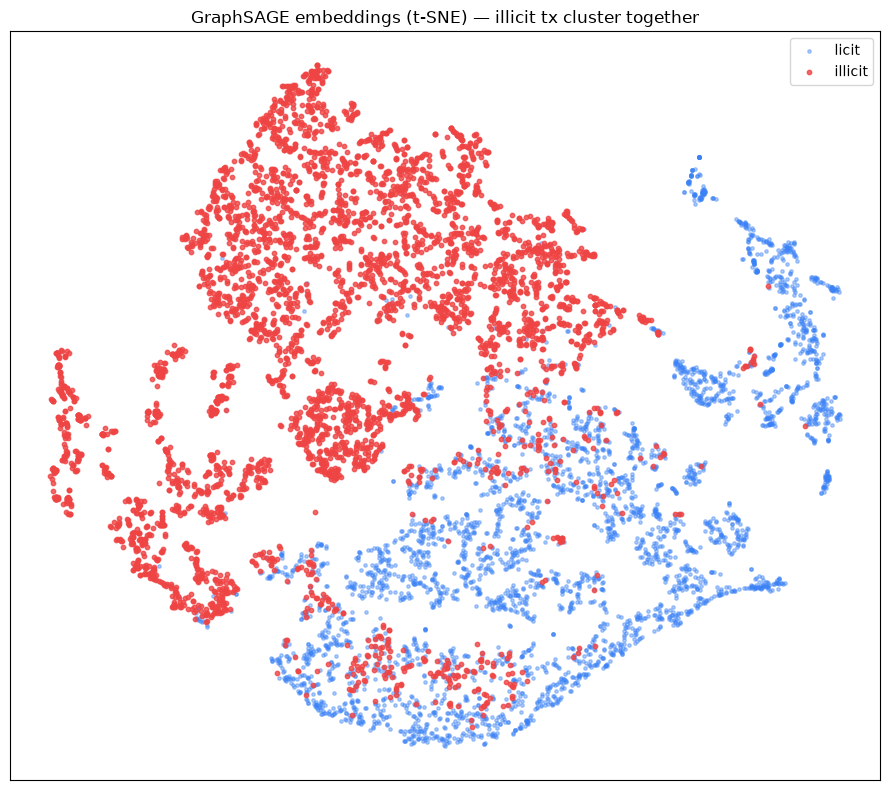

In [3]:
fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(proj[sel_labels == 0, 0], proj[sel_labels == 0, 1],
           s=6, c='#3b82f6', alpha=0.4, label='licit')
ax.scatter(proj[sel_labels == 1, 0], proj[sel_labels == 1, 1],
           s=10, c='#ef4444', alpha=0.8, label='illicit')
ax.set_title('GraphSAGE embeddings (t-SNE) — illicit tx cluster together')
ax.legend(); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig('embedding_tsne.png', dpi=150)
plt.show()

If the red (illicit) points form coherent clusters rather than being scattered uniformly through the blue, the GNN has learned the ring structure — that's the Phase 2 checkpoint met. `embedding_tsne.png` is the figure to drop into the README / interview writeup.